# 📄 File summary / 文件总览

**English**

This notebook turns a set of Phantom high-speed-camera spiracle-intensity recordings (one Excel file per fly) into a single peristimulus summary of how the spiracle opening responds to optogenetic stimulation.

For each fly it: (1) reads the raw spiracle-intensity trace from column E of the `.xlsx` (100 fps); (2) normalizes that trace per-fly so the 1st percentile = 0 and the 99th percentile = 1 (no clipping); (3) extracts three peristimulus windows (−2 s to +5 s, i.e. 700 frames) around the three optogenetic stimulus onsets at DAQ times 11 s / 21 s / 31 s; and (4) averages those three windows into one 700-sample trace for that fly. It then pools all flies into a grand mean ± SEM.

A key idea is **end-aligned timing**: the camera's recording *start* is imprecise (variable arm/buffer-fill time), but the *end* is exact — the last 10 frames are post-trigger, so `frame N−10` corresponds to DAQ t = 44.0 s. All stimulus-onset frame indices are computed backward from that trigger anchor, so each file is aligned correctly despite having a slightly different total length.

- **Inputs:** multiple `*PhantomCamera.xlsx` files (column E = spiracle intensity at 100 fps), selected via a glob pattern.
- **Outputs:** `peristimulus_summary.csv` (a `time_s` column from −2.0 to +4.99 s plus one column per fly) and `peristimulus_spiracle.svg` (publication-quality grand-mean ± SEM figure with stimulus onset/offset markers).
- **Project fit:** a self-contained Step-1 analysis for opto-triggered, immobilized-fly spiracle experiments. Unlike the main `step1_phantom_video_analysis` pipeline (which builds a 20 kHz `*_combined.csv`), this notebook works directly from the per-frame spiracle-intensity Excel exports and produces a peristimulus average without re-aligning to the NIDAQ grid.

**中文**

本 notebook 将一组 Phantom 高速相机记录的气门（spiracle）开合强度数据（每只果蝇一个 Excel 文件）整合为一份围绕光遗传刺激的"刺激周边期"（peristimulus）汇总，用于刻画气门开合对光遗传刺激的响应。

对每只果蝇：(1) 从 `.xlsx` 的 E 列读取原始气门强度时间序列（100 fps）；(2) 对该序列做逐果蝇归一化，使第 1 百分位映射为 0、第 99 百分位映射为 1（不做截断）；(3) 在 DAQ 时间 11 s / 21 s / 31 s 这三次光遗传刺激起始点附近，各截取一个刺激周边窗口（−2 s 至 +5 s，即 700 帧）；(4) 将这三个窗口平均成该果蝇的一条 700 点曲线。随后把所有果蝇汇总，计算总体均值 ± 标准误（SEM）。

核心思路是**末端对齐计时**：相机记录的*起点*并不精确（每次布防/缓冲填充耗时不定），但*终点*是精确的——最后 10 帧为触发后帧，因此 `第 N−10 帧`对应 DAQ 时间 44.0 s。所有刺激起始帧的索引都从这个触发锚点向前倒推计算，因此即使各文件总长度略有差异，也能正确对齐。

- **输入：** 多个 `*PhantomCamera.xlsx` 文件（E 列为 100 fps 的气门强度），通过 glob 通配符选取。
- **输出：** `peristimulus_summary.csv`（包含 −2.0 至 +4.99 s 的 `time_s` 列，以及每只果蝇一列）与 `peristimulus_spiracle.svg`（出版级的总体均值 ± SEM 图，并标注刺激起始/结束）。
- **项目定位：** 这是针对"光遗传触发、固定果蝇"气门实验的一个独立 Step-1 分析。与主流程 `step1_phantom_video_analysis`（生成 20 kHz 的 `*_combined.csv`）不同，本 notebook 直接基于逐帧气门强度的 Excel 导出数据，产出刺激周边平均曲线，而不重新对齐到 NIDAQ 时间网格。

---

**Imports & recording parameters** — Loads the libraries (NumPy, Matplotlib, `openpyxl` for Excel, `pathlib`, `glob`) and defines every fixed acquisition constant in one place: the camera frame rate (100 fps), the DAQ trigger time (44.0 s) and the 10 post-trigger frames that anchor the end-aligned timing, the three stimulus onset times (11 / 21 / 31 s) and 3 s duration, and the peristimulus window size (200 frames before + 500 after = 700 frames). It also precomputes `time_axis`, the shared −2.0 → +4.99 s time vector used by every output. Centralizing these constants means the whole analysis can be re-targeted by editing this one cell.

**导入库与记录参数** — 载入所需库（NumPy、Matplotlib、用于读取 Excel 的 `openpyxl`、`pathlib`、`glob`），并在此处集中定义所有固定的采集常量：相机帧率（100 fps）、DAQ 触发时间（44.0 s）以及用于末端对齐计时的 10 个触发后帧、三次刺激的起始时间（11 / 21 / 31 s）及 3 s 时长、刺激周边窗口大小（起始前 200 帧 + 起始后 500 帧 = 700 帧）。同时预先计算 `time_axis`，即所有输出共用的 −2.0 → +4.99 s 时间向量。把这些常量集中放置，意味着只需修改这一个单元即可调整整个分析的参数。

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from openpyxl import load_workbook
import glob

%matplotlib inline

# Recording parameters
FPS = 100                         # Phantom camera frame rate
TRIGGER_DAQ_TIME = 44.0           # DAQ time when trigger fires (s)
POST_TRIGGER_FRAMES = 10          # frames recorded after (and including) trigger

# Stimulus epochs in DAQ time (onset, offset)
STIM_DAQ_ONSETS = [11.0, 21.0, 31.0]  # DAQ times of stimulus onsets
STIM_DURATION_S = 3.0

# Peristimulus window
PRE_FRAMES = 200                  # 2 s before onset
POST_FRAMES = 500                 # 5 s after onset (onset frame inclusive)
WINDOW_LEN = PRE_FRAMES + POST_FRAMES   # 700 frames

# Time axis for the peristimulus window
time_axis = np.arange(-PRE_FRAMES, POST_FRAMES) / FPS  # -2.0 to +4.99 s

## 1. Select input files

Edit the glob pattern below to point at your `.xlsx` files (one per fly/trial).

**Select the input files** — This is the one cell you edit per analysis. The glob pattern collects every `*PhantomCamera.xlsx` file for the condition of interest (one file = one fly/trial), and `sorted()` gives a stable, reproducible order. An explicit list is offered as a commented-out alternative. The cell then prints how many files matched and their names, so you can confirm the right set was picked up before running anything heavy.

**选择输入文件** — 这是每次分析时需要修改的单元。glob 通配符会收集目标实验条件下的所有 `*PhantomCamera.xlsx` 文件（一个文件 = 一只果蝇/一次试验），`sorted()` 保证顺序稳定可复现。注释中还提供了直接显式列出文件路径的替代写法。该单元随后打印匹配到的文件数量及文件名，便于在执行后续耗时步骤前确认选取的文件集合是否正确。

In [30]:
# EDIT THIS: glob pattern or explicit list of paths
xlsx_paths = sorted(glob.glob('/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/DNg02_ChR_immobilized/*PhantomCamera.xlsx'))

# Or specify files explicitly:
# xlsx_paths = [
#     "/path/to/fly1.xlsx",
#     "/path/to/fly2.xlsx",
# ]

print(f"Found {len(xlsx_paths)} file(s):")
for p in xlsx_paths:
    print(f"  {Path(p).name}")

Found 10 file(s):
  2026_0417_141448_DNg02_ChR_SS01562_ChR_4d_F_Fly2_Trial1_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0417_143037_DNg02_ChR_SS01562_ChR_4d_F_Fly3_Trial1_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0417_151213_DNg02_ChR_SS01562_ChR_4d_F_Fly4_Trial1_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0417_152622_DNg02_ChR_SS01562_ChR_4d_F_Fly5_Trial2_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0417_153710_DNg02_ChR_SS01562_ChR_4d_F_Fly6_Trial1_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0417_154457_DNg02_ChR_SS01562_ChR_4d_F_Fly7_Trial2_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0422_161502_DNg02_ChR_SS01562_ChR_4d_F_Fly8_Trial1_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0422_162412_DNg02_ChR_SS01562_ChR_4d_F_Fly9_Trial2_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0422_162645_DNg02_ChR_SS01562_ChR_4d_F_Fly10_Trial1_3x3000ms_sp1_PhantomCamera.xlsx
  2026_0422_163303_DNg02_ChR_SS01562_ChR_4d_F_Fly11_Trial1_3x3000ms_sp1_PhantomCamera.xlsx


## 2. Helper functions

Frame-to-DAQ alignment is done from the **end** of the recording.  
The trigger frame is at index `N - POST_TRIGGER_FRAMES`, corresponding to DAQ t = 44.0 s.  
All stimulus onset indices are computed relative to this anchor.

**Helper functions** — Defines the four building blocks used by the processing loop:

- `read_column_e` — opens an `.xlsx` read-only and pulls column E from row 2 down into a float array, stopping at the first empty cell. (`openpyxl` is used deliberately instead of pandas to avoid Excel-engine issues.)
- `normalize_trace` — the per-fly normalization: maps the trace's 1st percentile to 0 and 99th percentile to 1 without clipping, and guards against a flat trace where the two percentiles coincide.
- `compute_stim_onset_frames` — the heart of the end-aligned timing: the trigger frame is `N − POST_TRIGGER_FRAMES` (DAQ 44.0 s), and each stimulus onset frame is found by stepping back `(44.0 − t_daq)·FPS` frames from there.
- `extract_peristimulus` — for one fly, slices the −200/+500-frame window around each of the three onsets, skips (with a warning) any window that runs past the data edges, prints a sanity-check of the inferred recording start, and returns the average of the valid windows (or `None` if none are valid).

**辅助函数** — 定义处理循环所用的四个基础函数：

- `read_column_e` — 以只读方式打开 `.xlsx`，从第 2 行起向下读取 E 列至首个空单元格，返回浮点数组。（此处刻意使用 `openpyxl` 而非 pandas，以避免 Excel 读取引擎的兼容问题。）
- `normalize_trace` — 逐果蝇归一化：将序列的第 1 百分位映射为 0、第 99 百分位映射为 1，且不做截断；同时对两个百分位相等（曲线平坦）的情况做了保护。
- `compute_stim_onset_frames` — 末端对齐计时的核心：触发帧为 `N − POST_TRIGGER_FRAMES`（对应 DAQ 44.0 s），每个刺激起始帧则由此向前回退 `(44.0 − t_daq)·FPS` 帧得到。
- `extract_peristimulus` — 针对单只果蝇，在三个起始点附近各截取 −200/+500 帧的窗口；若窗口超出数据边界则跳过并发出警告；打印推断出的记录起始时间以供核对；最后返回所有有效窗口的平均（若无有效窗口则返回 `None`）。

In [25]:
def read_column_e(fpath):
    """Read column E from E2 downward, returning a float64 array."""
    wb = load_workbook(fpath, read_only=True, data_only=True)
    ws = wb.active
    raw_values = []
    for row in ws.iter_rows(min_row=2, min_col=5, max_col=5):
        val = row[0].value
        if val is None:
            break
        raw_values.append(float(val))
    wb.close()
    return np.array(raw_values, dtype=np.float64)


def normalize_trace(trace):
    """Normalize: 1st percentile -> 0, 99th percentile -> 1. No clipping."""
    p1 = np.percentile(trace, 1)
    p99 = np.percentile(trace, 99)
    if p99 == p1:
        print(f"  WARNING: 1st and 99th percentiles identical ({p1}). Returning zeros.")
        return np.zeros_like(trace)
    return (trace - p1) / (p99 - p1)


def compute_stim_onset_frames(n_frames):
    """
    Compute stimulus onset frame indices using end-aligned timing.

    The trigger frame is at index (n_frames - POST_TRIGGER_FRAMES),
    corresponding to DAQ t = TRIGGER_DAQ_TIME.
    For a stimulus at DAQ time t_daq:
        frame_index = trigger_frame - round((TRIGGER_DAQ_TIME - t_daq) * FPS)
    """
    trigger_frame = n_frames - POST_TRIGGER_FRAMES
    onset_frames = []
    for t_daq in STIM_DAQ_ONSETS:
        offset_from_trigger = round((TRIGGER_DAQ_TIME - t_daq) * FPS)
        frame_idx = trigger_frame - offset_from_trigger
        onset_frames.append(frame_idx)
    return trigger_frame, onset_frames


def extract_peristimulus(norm_trace, fly_name):
    """Extract peristimulus windows for the 3 stimulus epochs, return their average."""
    n_frames = len(norm_trace)
    trigger_frame, onset_frames = compute_stim_onset_frames(n_frames)

    # Report the inferred start time for sanity checking
    first_frame_daq = TRIGGER_DAQ_TIME - (trigger_frame / FPS)
    print(f"  Trigger frame: {trigger_frame} (of {n_frames})")
    print(f"  Inferred DAQ time of first frame: {first_frame_daq:.3f} s")

    epoch_traces = []
    for i, onset in enumerate(onset_frames):
        win_start = onset - PRE_FRAMES
        win_end = onset + POST_FRAMES  # exclusive

        if win_start < 0 or win_end > n_frames:
            print(f"  WARNING: Stimulus {i+1} (onset frame {onset}) window "
                  f"[{win_start}:{win_end}] exceeds data range [0:{n_frames}]. "
                  "Skipping this epoch.")
            continue

        epoch_traces.append(norm_trace[win_start:win_end])
        print(f"  Stimulus {i+1} (DAQ {STIM_DAQ_ONSETS[i]:.0f}s): "
              f"onset frame {onset}, window [{win_start}:{win_end - 1}]")

    if len(epoch_traces) == 0:
        print(f"  WARNING: No valid epochs for {fly_name}. Skipping.\n")
        return None

    avg = np.mean(np.array(epoch_traces), axis=0)
    print(f"  Averaged {len(epoch_traces)} epoch(s).\n")
    return avg

## 3. Process all files

**Process all files** — The main loop. For every selected file it reads column E, normalizes the trace, and extracts the per-fly peristimulus average, printing progress and frame counts along the way. Flies that yield a valid average are accumulated into `fly_names` and `fly_traces`; flies with no usable epochs are dropped. An assertion stops execution if nothing survived. Finally the per-fly traces are stacked column-wise into `fly_matrix` (shape `700 × n_flies`), the data structure every later cell builds on.

**处理所有文件** — 主循环。对每个选中的文件，读取 E 列、归一化序列、提取该果蝇的刺激周边平均曲线，并在过程中打印进度与帧数。能得到有效平均的果蝇会被累加进 `fly_names` 和 `fly_traces`；没有可用刺激段的果蝇则被丢弃。若最终无任何数据存活，断言会中止执行。最后将各果蝇曲线按列堆叠为 `fly_matrix`（形状 `700 × 果蝇数`），这是后续所有单元所依赖的数据结构。

In [26]:
fly_names = []
fly_traces = []

for fpath in xlsx_paths:
    fname = Path(fpath).stem
    print(f"Processing: {fname}")

    trace = read_column_e(fpath)
    print(f"  Total frames: {len(trace)}")

    norm_trace = normalize_trace(trace)
    avg_trace = extract_peristimulus(norm_trace, fname)

    if avg_trace is not None:
        fly_names.append(fname)
        fly_traces.append(avg_trace)

assert len(fly_traces) > 0, "No valid data after processing!"

fly_matrix = np.column_stack(fly_traces)  # (700, n_flies)
n_flies = fly_matrix.shape[1]
print(f"Successfully processed {n_flies} fly/flies.")

Processing: 2026_0417_141448_DNg02_ChR_SS01562_ChR_4d_F_Fly2_Trial1_3x3000ms_sp1_PhantomCamera
  Total frames: 4045
  Trigger frame: 4035 (of 4045)
  Inferred DAQ time of first frame: 3.650 s
  Stimulus 1 (DAQ 11s): onset frame 735, window [535:1234]
  Stimulus 2 (DAQ 21s): onset frame 1735, window [1535:2234]
  Stimulus 3 (DAQ 31s): onset frame 2735, window [2535:3234]
  Averaged 3 epoch(s).

Processing: 2026_0417_143037_DNg02_ChR_SS01562_ChR_4d_F_Fly3_Trial1_3x3000ms_sp1_PhantomCamera
  Total frames: 4275
  Trigger frame: 4265 (of 4275)
  Inferred DAQ time of first frame: 1.350 s
  Stimulus 1 (DAQ 11s): onset frame 965, window [765:1464]
  Stimulus 2 (DAQ 21s): onset frame 1965, window [1765:2464]
  Stimulus 3 (DAQ 31s): onset frame 2965, window [2765:3464]
  Averaged 3 epoch(s).

Processing: 2026_0417_151213_DNg02_ChR_SS01562_ChR_4d_F_Fly4_Trial1_3x3000ms_sp1_PhantomCamera
  Total frames: 4252
  Trigger frame: 4242 (of 4252)
  Inferred DAQ time of first frame: 1.580 s
  Stimulus 1 (

## 4. Grand mean and SEM

**Grand mean and SEM** — Collapses `fly_matrix` across flies into the population summary: `grand_mean` is the across-fly mean at each of the 700 time points, and `grand_sem` is the standard error of the mean (sample SD with `ddof=1`, divided by √n). With only one fly the SEM is undefined, so it is set to zeros and a note is printed. These two 700-point vectors are what the figure draws.

**总体均值与标准误（SEM）** — 将 `fly_matrix` 沿果蝇维度汇总为群体统计量：`grand_mean` 为 700 个时间点上各果蝇的均值，`grand_sem` 为均值的标准误（样本标准差，`ddof=1`，再除以 √n）。当只有一只果蝇时 SEM 无定义，故置为 0 并打印提示。这两条 700 点向量即为后续作图所用的数据。

In [27]:
grand_mean = np.mean(fly_matrix, axis=1)

if n_flies > 1:
    grand_sem = np.std(fly_matrix, axis=1, ddof=1) / np.sqrt(n_flies)
else:
    grand_sem = np.zeros_like(grand_mean)
    print("Only 1 fly -- SEM is zero.")

## 5. Save summary CSV

**Save summary CSV** — Writes `peristimulus_summary.csv` into `input_folder` (the directory holding the input `.xlsx` files). The file has a `time_s` first column (−2.0 → +4.99 s) followed by one column per fly, headers being the filenames; rows are the 700 peristimulus samples. This is the machine-readable companion to the figure, suitable for re-plotting or stats elsewhere.

> Note: `input_folder` is used here but is not assigned in any cell above — it must be defined elsewhere in the session before this cell runs (e.g. as the parent directory of the selected `.xlsx` files). Flagged for your awareness; the code itself is left unchanged.

**保存汇总 CSV** — 将 `peristimulus_summary.csv` 写入 `input_folder`（即存放输入 `.xlsx` 文件的目录）。文件首列为 `time_s`（−2.0 → +4.99 s），其后每只果蝇一列、列名为文件名；每行对应 700 个刺激周边采样点。这是图像之外的机器可读版本，便于在别处重新绘图或做统计分析。

> 注意：此处使用了 `input_folder`，但上方任何单元都未对其赋值——它必须在本单元运行前于会话中的其他位置定义（例如定义为所选 `.xlsx` 文件的上级目录）。此处仅作提示，代码本身保持不变。

In [28]:
# Save outputs next to the input xlsx files folder
csv_path = input_folder / "peristimulus_summary.csv"

header = "time_s," + ",".join(fly_names)
data_block = np.column_stack([time_axis, fly_matrix])
np.savetxt(csv_path, data_block, delimiter=",", header=header,
           comments="", fmt="%.6f")
print(f"CSV saved to: {csv_path}")

CSV saved to: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/DNg02_ChR_immobilized/peristimulus_summary.csv


## 6. Plot and save SVG

**Plot and save SVG** — Builds the publication-quality figure and writes it to `peristimulus_spiracle.svg` (also in `input_folder`). It draws the SEM band as a translucent fill, the grand mean as a solid line, a dashed vertical line at t = 0 (stimulus onset) and a dotted one at t = 3 s (offset), labels the axes, fixes the x-range to −2 → 5 s and y-range to 0 → 1, and applies clean styling (no top/right spines, no grid). The title reports the fly count `n`. The figure is saved as SVG (vector, editable in Illustrator) and shown inline.

**绘图并保存 SVG** — 生成出版级图像并写入 `peristimulus_spiracle.svg`（同样位于 `input_folder`）。图中以半透明填充表示 SEM 区间，以实线表示总体均值，在 t = 0（刺激起始）画虚线、在 t = 3 s（刺激结束）画点线；标注坐标轴，将 x 轴固定为 −2 → 5 s、y 轴固定为 0 → 1，并采用简洁样式（隐藏上、右边框，无网格）。标题中标明果蝇数量 `n`。图像以 SVG 矢量格式保存（可在 Illustrator 中编辑），并内嵌显示。

SVG saved to: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/DNg02_ChR_immobilized/peristimulus_spiracle.svg


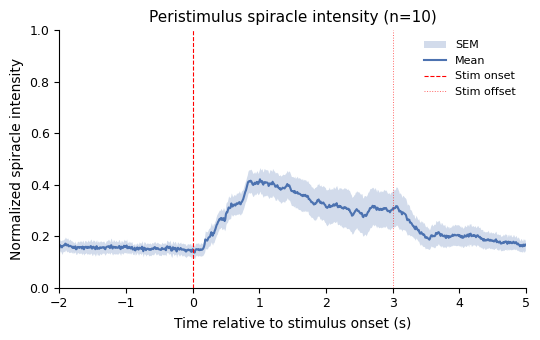

In [29]:
# Save outputs next to the input xlsx files folder
svg_path = input_folder / "peristimulus_spiracle.svg"

fig, ax = plt.subplots(figsize=(5.5, 3.5))

# SEM shading
ax.fill_between(time_axis,
                grand_mean - grand_sem,
                grand_mean + grand_sem,
                color="#4C72B0", alpha=0.25, linewidth=0, label="SEM")

# Grand mean
ax.plot(time_axis, grand_mean, color="#4C72B0", linewidth=1.5, label="Mean")

# Stimulus onset/offset markers
ax.axvline(0, color="red", linestyle="--", linewidth=0.8, label="Stim onset")
ax.axvline(STIM_DURATION_S, color="red", linestyle=":", linewidth=0.7,
           alpha=0.6, label="Stim offset")

ax.set_xlabel("Time relative to stimulus onset (s)", fontsize=10)
ax.set_ylabel("Normalized spiracle intensity", fontsize=10)
ax.set_xlim(-2, 5)
ax.set_ylim(0, 1)
ax.set_title(f"Peristimulus spiracle intensity (n={n_flies})", fontsize=11)
ax.tick_params(labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=8, frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig(svg_path, format="svg")
print(f"SVG saved to: {svg_path}")
plt.show()